In [ ]:
### pyFIA Functions (for Maine) - Jupyter Notebook Demo ###
# -*- coding: utf-8 -*-
#Credits
"""
Created on Mon Oct 28 08:34:18 2024
@author: xinyuan.wei, gregory.mchale
"""

In [1]:
# Load in required packages
import pandas as pd
import geopandas as gpd

In [2]:
# Import supplementary Python scripts contained in larger pyFIA folder
# Ensure these scripts are in your working directory before running
import _pyFIA_Plot_Stats as ps
import _pyFIA_Regional_Stats as rs
import _pyFIA_Visualization as vl
import _pyFIA_Interpolation as ip
import _pyFIA_Climate as cl
import _pyFIA_Bookkeeping as bk

In [3]:
# Select desired state (postal code) and corresponding Federal Information Processing Standards (FIPS) code. 
# Ensure that state's FIA data is contained in your working directory. In this notebook, we will use Maine (ME). 
State = 'ME'
FIPS = '23'

In [4]:
# Load the FIA Tree, Condition, Plot, County, Pop_stratum, Pop_Stratum_Assgn data .csvs
FIA_Data = {
    'tree_data': pd.read_csv(f'{State}_CSV/{State}_TREE.csv', low_memory=False),
    'cond_data': pd.read_csv(f'{State}_CSV/{State}_COND.csv', low_memory=False),
    'plot_data': pd.read_csv(f'{State}_CSV/{State}_PLOT.csv', low_memory=False),
    'coty_data': pd.read_csv(f'{State}_CSV/{State}_COUNTY.csv', low_memory=False),
    'tgrm_data': pd.read_csv(f'{State}_CSV/{State}_TREE_GRM_ESTN.csv', low_memory=False),
    'pops_data': pd.read_csv(f'{State}_CSV/{State}_POP_STRATUM.csv', low_memory=False),
    'popp_data': pd.read_csv(f'{State}_CSV/{State}_POP_PLOT_STRATUM_ASSGN.csv', low_memory=False)
}

In [5]:
# Load the U.S. basemap (shapefile). This is a shapefile of every U.S. state and county, enabling generation of FIA data maps of whole states
# or specific counties. 
basemap = gpd.read_file('_US_Boundary/us_boundary.shp')

In [6]:
###----------------------------------------------------------------------------
# STATEWIDE PLOT-LEVEL FOREST ANALYSES
###----------------------------------------------------------------------------
# The below analyses calculate statewide forest metrics using all of the FIA inventory plots in a state
# Results of the functions are exported to the folder "_Results" in your working directory
# Check the FIA User Guide for species and species group codes

In [7]:
# Statewide plot-level statistics for DBH (cm) and height (m)
savefile = f'_Results/{State}_Plot_DBH_H_Stats.csv'
plot_D_H_stats = ps.plot_D_H_stats(FIA_Data=FIA_Data, 
                                   inv_yr=2023,          # The ending inventory year - most recent inventory cycle in Maine
                                   n_years=5,            # Inventory cycle (years) - Maine is 5 years, though western states are typically 10
                                   tree_size=0,          # Minimum tree diameter (cm)
                                   tree_spp=[],          # Species (empty-all species) - use the 2-3 digit species code for specific spp. (e.g. red spruce = 97)
                                   tree_spg=[])          # species group (empty-all species)  
plot_D_H_stats.to_csv(savefile, index=False)
print(plot_D_H_stats.head(5)) # Displays the first 5 rows of the output .csv

   INVYR  PLOT       LAT       LON  Mean_DBH_cm  STD_DBH_cm  Max_DBH_cm  \
0   2019     1  45.20345 -68.75708    21.209000    7.532379      38.100   
1   2019     9  45.35346 -68.17171    12.954000    7.263353      31.496   
2   2019    10  43.90212 -70.74017    11.237576    8.811647      33.782   
3   2019    16  46.07783 -69.55849     9.768237    5.881721      24.638   
4   2019    20  44.92017 -68.94388    17.617722    7.023365      33.782   

    Mean_H_m   STD_H_m   Max_H_m  FORTYPCD  STDAGE  COUNTYCD  
0  13.198706  2.466674  19.20366     902.0    47.0        19  
1  10.465487  3.003018  15.24100     801.0    87.0        19  
2   9.320102  2.771841  16.76510     801.0    38.0         5  
3   7.615334  3.684672  16.15546     121.0    38.0        21  
4  12.099661  4.619274  21.94704     801.0    64.0        19  


In [8]:
# Statewide plot-level structure metrics
savefile = f'_Results/{State}_Plot_Structure_Metrics.csv'
plot_metrics = ps.plot_str_metrics(FIA_Data=FIA_Data, 
                                   inv_yr=2023,          # The ending inventory year
                                   n_years=5,            # Inventory cycle (years) 
                                   tree_size=0,          # Minimum tree diameter (cm)
                                   tree_spp=[],          # Species (empty-all species)
                                   tree_spg=[],          # species group (empty-all species) 
                                   top_percents=None)    # Top percent (None or [15])    
plot_metrics.to_csv(savefile, index=False)
print(plot_metrics.iloc[:, :10].head()) # Only displays first 10 columns here

   INVYR  PLOT       LAT       LON  top10_height_count  avg_top10_height_m  \
0   2019     1  45.20345 -68.75708                 2.0           16.917510   
1   2019     9  45.35346 -68.17171                 4.0           14.326540   
2   2019    10  43.90212 -70.74017                 4.0           14.478950   
3   2019    16  46.07783 -69.55849                 6.0           14.682163   
4   2019    20  44.92017 -68.94388                 4.0           20.422940   

   top10_dbh_count  avg_top10_dbh_cm  top25_height_count  avg_top25_height_m  
0              2.0         33.528000                 5.0           15.362928  
1              3.0         26.585333                 8.0           13.640695  
2              4.0         29.083000                 9.0           12.870178  
3              6.0         20.277667                15.0           12.680512  
4              4.0         31.051500                 9.0           18.052118  


In [9]:
# Statewide plot-level forest structure indices
savefile = f'_Results/{State}_Plot_Structure_Indices.csv'
plot_indices = ps.plot_str_indices(FIA_Data=FIA_Data, 
                                   inv_yr=2023,          # The ending inventory year
                                   n_years=5,            # Inventory cycle (years) 
                                   tree_size=0,          # Minimum tree diameter (cm)
                                   tree_spp=[],          # Species (empty-all species)
                                   tree_spg=[])          # species group (empty-all species)   
plot_indices.to_csv(savefile, index=False)
print(plot_indices.head())

   INVYR  PLOT       LAT       LON     QMD_cm       CRR      FVSS     BA_m2  \
0   2019     1  45.20345 -68.75708  22.443742  0.530952  0.186888  0.791244   
1   2019     9  45.35346 -68.17171  14.792020  0.587719  0.286945  0.515544   
2   2019    10  43.90212 -70.74017  14.197724  0.357257  0.297405  0.522446   
3   2019    16  46.07783 -69.55849  11.376588  0.377401  0.483849  0.599744   
4   2019    20  44.92017 -68.94388  18.929912  0.461574  0.381769  1.013187   

          TPA  TreeCount  FORTYPCD  STDAGE  COUNTYCD  
0  120.360926       20.0     902.0    47.0        19  
1  180.541389       30.0     801.0    87.0        19  
2  198.595527       33.0     801.0    38.0         5  
3  355.064731       59.0     121.0    38.0        21  
4  216.649666       36.0     801.0    64.0        19  


In [10]:
# Statewide plot-level forest composition
# Uses the Shannon Index
savefile = f'_Results/{State}_Plot_Composition.csv'
plot_composition = ps.plot_composition(FIA_Data=FIA_Data,
                                       inv_yr=2023,      # The ending inventory year
                                       n_years=5)        # Inventory cycle (years)
plot_composition.to_csv(savefile, index=False) 
print(plot_composition.head())

   INVYR  PLOT       LAT       LON   Shannon  Evenness  Richness  \
0   2019     1  45.20345 -68.75708  1.228492  0.886169       4.0   
1   2019     9  45.35346 -68.17171  1.724794  0.784988       9.0   
2   2019    10  43.90212 -70.74017  1.059169  0.544305       7.0   
3   2019    16  46.07783 -69.55849  1.355586  0.696633       7.0   
4   2019    17  47.22813 -69.35207  0.000000  0.000000       1.0   

   Dominant_count  Dominant_count_prop  Dominant_ba  Dominant_ba_prop  \
0            12.0             0.380952        316.0          0.426662   
1           316.0             0.340426        531.0          0.392868   
2           531.0             0.727273        531.0          0.305297   
3            12.0             0.513514         12.0          0.411791   
4           371.0             1.000000        371.0          0.000000   

      BA_m2  FORTYPCD  STDAGE  COUNTYCD  
0  0.791244     902.0    47.0        19  
1  0.515544     801.0    87.0        19  
2  0.522446     801.0    3

In [11]:
# Statewide plot-level fraction
# Fraction of total trees within each FIA plot that are a given species
# In this example, we chose red spruce, Picea rubens
savefile = f'_Results/{State}_Plot_Species_Proportion.csv'
plot_f_species = ps.plot_f_species(FIA_Data=FIA_Data,
                                   inv_yr=2023,          # The ending inventory year
                                   n_years=5,            # Inventory cycle (years)
                                   SP=[97])              # Species list (this just uses red spruce (97), for more species, seperate with commas)
plot_f_species.to_csv(savefile, index=False) 
print(plot_f_species.head())

   INVYR  PLOT       LAT       LON  COUNTYCD  t_count  sp_count    f_tree  \
0   2019     1  45.20345 -68.75708        19       21       0.0  0.000000   
1   2019     9  45.35346 -68.17171        19       47       1.0  0.021277   
2   2019    10  43.90212 -70.74017         5       33       0.0  0.000000   
3   2019    16  46.07783 -69.55849        21       74      11.0  0.148649   
4   2019    17  47.22813 -69.35207         3        2       0.0  0.000000   

     f_stem  FORTYPCD  STDAGE  
0  0.000000     902.0    47.0  
1  0.127732     801.0    87.0  
2  0.000000     801.0    38.0  
3  0.234816     121.0    38.0  
4       NaN     124.0     6.0  


In [12]:
# Statewide plot-level aboveground, belowground, and total biomass (kgC/m²)
savefile = f'_Results/{State}_Plot_Biomass.csv'
plot_biomass = ps.plot_biomass(FIA_Data=FIA_Data, 
                               inv_yr=2023,          # The ending inventory year
                               n_years=5,            # Inventory cycle (years) 
                               tree_size=0,          # Minimum tree diameter (cm)
                               tree_spp=[],          # Species (empty-all species)
                               tree_spg=[])          # species group (empty-all species)   
plot_biomass.to_csv(savefile, index=False)
print(plot_biomass.head())

   INVYR  PLOT       LAT       LON  FORTYPCD  STDAGE  AGB_kgC/m2  BGB_kgC/m2  \
0   2019     1  45.20345 -68.75708     902.0    47.0    1.581075    0.294058   
1   2019     9  45.35346 -68.17171     801.0    87.0    1.540129    0.294985   
2   2019    10  43.90212 -70.74017     801.0    38.0    1.494187    0.271923   
3   2019    16  46.07783 -69.55849     121.0    38.0    1.412444    0.247184   
4   2019    20  44.92017 -68.94388     801.0    64.0    3.161225    0.570377   

   TB_kgC/m2  
0   1.875133  
1   1.835113  
2   1.766110  
3   1.659628  
4   3.731602  


In [13]:
# Statewide plot-level harvested volume
savefile = f'_Results/{State}_Plot_Harvested_Volume.csv'
plot_harvest = ps.plot_harvest(FIA_Data=FIA_Data, 
                               sta_yr=2000,        # The starting year 
                               end_yr=2023,        # The ending year
                               land='FORESTLAND',  # Land type
                               etype='GS',         # Use growing stock removals  
                               units='CF')         # Use cubic feet
plot_harvest.to_csv(savefile, index=False)
print(plot_harvest.head())

   INVYR  PLOT  Volume(ft3)  Harvested(ft3)  Fraction
0   2000     4  1018.393471             NaN       NaN
1   2000     6   661.379675             NaN       NaN
2   2000     7   480.025184             NaN       NaN
3   2000     8  1201.470946             NaN       NaN
4   2000    11   225.509351             NaN       NaN


In [14]:
# Statewide plot-level forest type and type group
savefile = f'_Results/{State}_Plot_ForestType.csv'
plot_type = ps.plot_type(FIA_Data=FIA_Data,
                         sta_yr=2019,          # The starting year
                         end_yr=2023)          # The ending year
plot_type.to_csv(savefile, index=False)
print(plot_type.head())

INVYR  PLOT   2019   2020   2021  2022  2023  TYPGRPCD_2019  TYPGRPCD_2020  \
0         1  902.0    NaN    NaN   NaN   NaN          910.0            NaN   
1         2    NaN    NaN  801.0   NaN   NaN            NaN            NaN   
2         3    NaN    NaN  121.0   NaN   NaN            NaN            NaN   
3         4    NaN  121.0    NaN   NaN   NaN            NaN          120.0   
4         5    NaN    NaN  801.0   NaN   NaN            NaN            NaN   

INVYR  TYPGRPCD_2021  TYPGRPCD_2022  TYPGRPCD_2023  
0                NaN            NaN            NaN  
1              900.0            NaN            NaN  
2              120.0            NaN            NaN  
3                NaN            NaN            NaN  
4              900.0            NaN            NaN  


In [15]:
###----------------------------------------------------------------------------
# REGIONAL FOREST BIOMASS AND OTHER ATTRIBUTES SUMMARY
###----------------------------------------------------------------------------

In [16]:
# State forest biomass/carbon storage summary
start_yr = 2019
end_yr   = 2023 # Most recent inventory cycle for Maine
state_biomass = rs.state_biomass(FIA_Data=FIA_Data,
                                 inv_yr=end_yr,          # The ending inventory year
                                 n_years=5,              # Inventory cycle (years)                           
                                 tree_size=0,            # Minimum tree diameter (cm)
                                 tree_spp=[],            # Species (empty-all species)
                                 tree_spg=[])            # species group (empty-all species)
 
print(f'{State} State Forest Biomass/Carbon Summary ({start_yr}–{end_yr}):')
for key, value in state_biomass.items():
    print(f'{key}: {value}')

ME State Forest Biomass/Carbon Summary (2019–2023):
Aboveground Biomass (TgC): 392.1
Belowground Biomass (TgC): 73.4
Total Biomass (TgC): 465.49


In [17]:
# County forest biomass/carbon density
county_biomass = rs.county_biomass(FIA_Data=FIA_Data,
                                   inv_yr=2023,            # The ending inventory year
                                   n_years=5,              # Inventory cycle (years)
                                   tree_size=0,            # Minimum tree diameter (cm)
                                   tree_spp=[],            # Species (empty-all species)
                                   tree_spg=[])            # species group (empty-all species)

savefile = f'_Results/{State}_County_Biomass_Density.csv'
county_biomass.to_csv(savefile, index=False)   
print(f'{State} County Level Biomass/Carbon Density:')
print(county_biomass) 

ME County Level Biomass/Carbon Density:
        COUNTYNM  AGB(kg/m2)  BGB(kg/m2)  TB(kg/m2)
0   Androscoggin    3.147775    0.602181   3.749957
1      Aroostook    3.392838    0.624330   4.017168
2     Cumberland    4.332087    0.847552   5.179639
3       Franklin    3.981485    0.758643   4.740127
4        Hancock    3.971528    0.731036   4.702564
5       Kennebec    3.593799    0.678066   4.271866
6           Knox    3.584033    0.666418   4.250451
7        Lincoln    4.095248    0.778946   4.874194
8         Oxford    4.725876    0.911697   5.637573
9      Penobscot    3.750046    0.694114   4.444161
10   Piscataquis    4.166097    0.781476   4.947573
11     Sagadahoc    4.616981    0.864309   5.481290
12      Somerset    3.522091    0.664192   4.186283
13         Waldo    4.204077    0.777346   4.981424
14    Washington    3.624107    0.657037   4.281145
15          York    4.038874    0.781229   4.820103


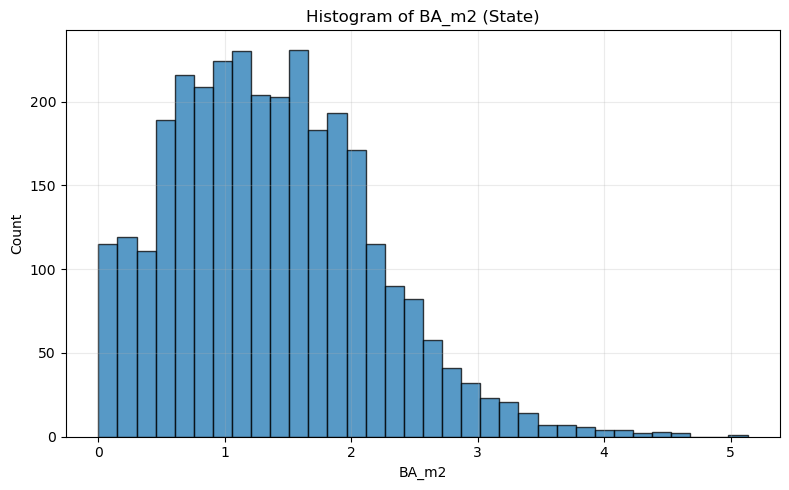

State Summary For BA_m2:
Count: 3110
Mean: 1.3782
Std: 0.7895
Coefficient Of Variation: 0.5729
Min: 0.0005
5%: 0.2132
25%: 0.7730
Median: 1.3090
75%: 1.9011
95%: 2.7651
Max: 5.1343
IQR: 1.1281
Skewness: 0.6139
Kurtosis: 0.4438


In [18]:
# State-level summary for a forest variable
data     = '_Results/ME_Plot_Structure_Indices.csv'
var      = 'BA_m2' # Select variable from structure indices csv
state_summary = rs.state_summary(data, var)

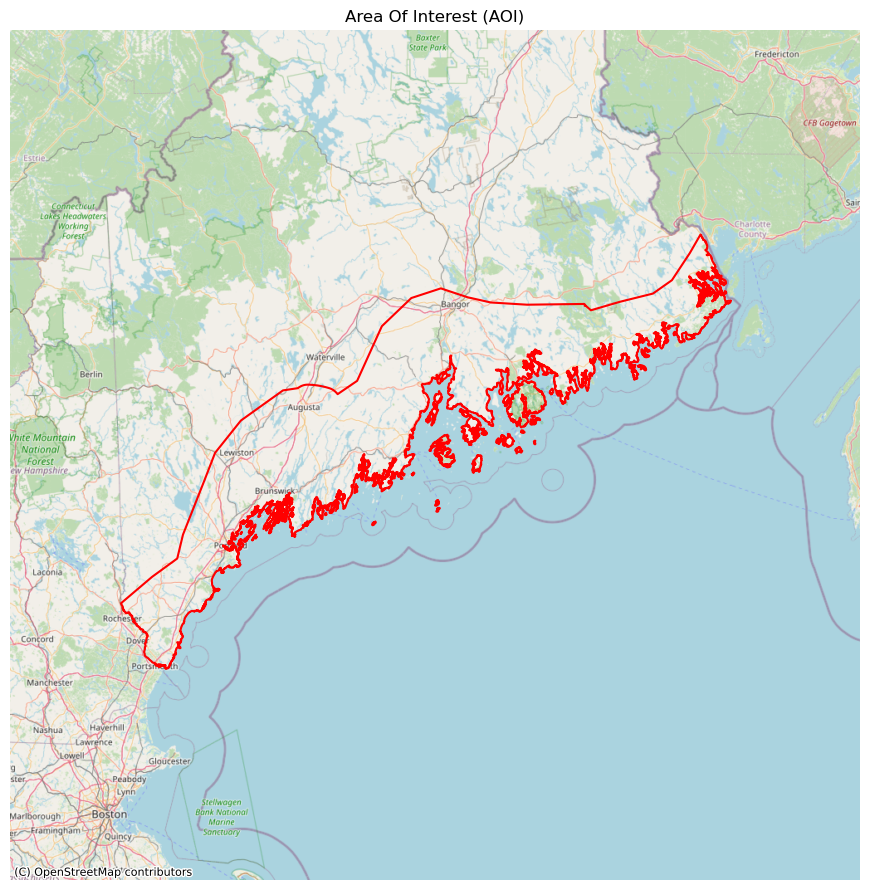

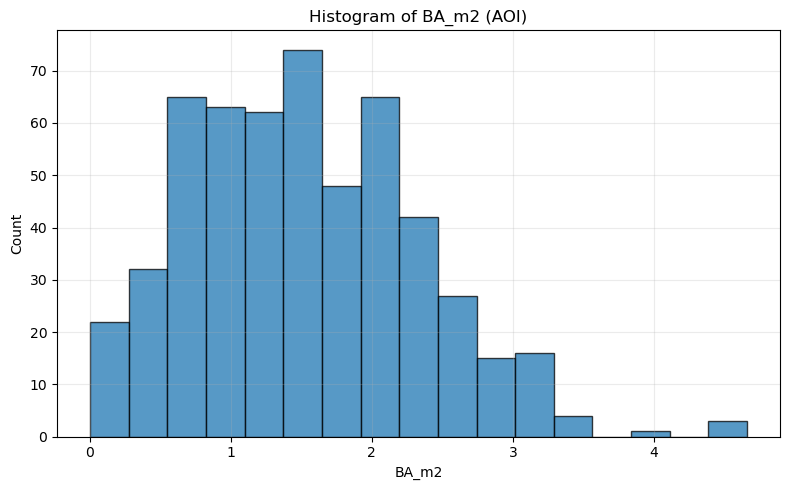

AOI Summary For BA_m2:
Count: 539
Mean: 1.5317
Std: 0.8071
Coefficient Of Variation: 0.5269
Min: 0.0006
5%: 0.3425
25%: 0.9309
Median: 1.4786
75%: 2.0943
95%: 2.9657
Max: 4.6606
IQR: 1.1634
Skewness: 0.5184
Kurtosis: 0.2618


In [19]:
# Area of Interest (AOI) summary
# Extract forest attribute data from user-specified AOI
data     = '_Results/ME_Plot_Structure_Indices.csv'
AOI      = '_AOI/Coastal_Region.shp'
var      = 'BA_m2' 
savefile = '_Results/AOI_Coastal_Data.csv'
AOI_summary = rs.AOI_summary(data=data, 
                             AOI=AOI,
                             savefile=savefile,
                             var=var)

In [20]:
###----------------------------------------------------------------------------
# FOREST ATTRIBUTE VISUALIZATION
###----------------------------------------------------------------------------
# These functions create maps of FIA plots across a state and symbolize them by: BA, TPA, AGB, and carbon density
# Visualizations can be adjusted to only display metrics of specicifc species, species groups, or inventory periods

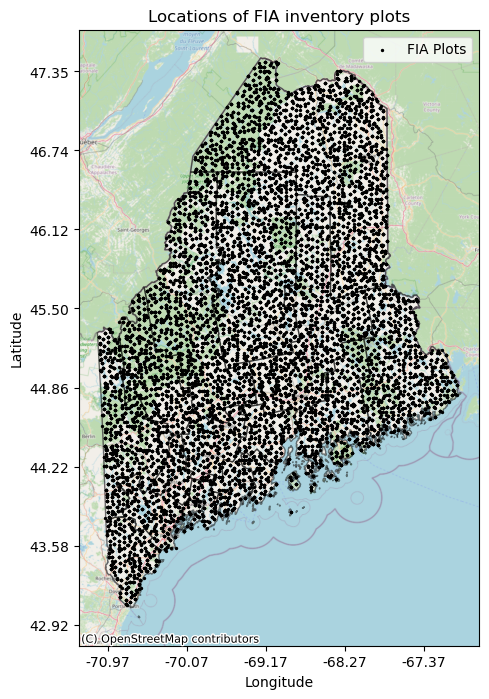

In [21]:
# Visualize all the inventory plots for a given state
savefile = f'_Results/{State}_FIA_Plots.png'
vl.plot_map(FIA_Data=FIA_Data, 
            basemap=basemap, 
            FIPS=FIPS, 
            savefile=savefile)

C:\Users\gregory.mchale\AppData\Local\minifor\envs\pyFIA_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=13.
  warnings.warn(


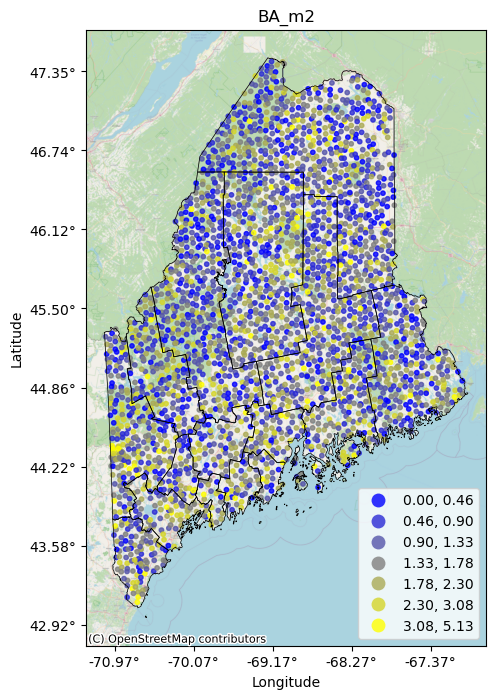

In [22]:
# Statewide plot-level basal area (BA) visualization
savefile = f'_Results/{State}_BA.png'
data     = '_Results/ME_Plot_Structure_Indices.csv'
var      = 'BA_m2'
vl.plot_forest_map(data=data,
                   var=var,
                   basemap=basemap,
                   FIPS=FIPS,
                   savefile=savefile)

C:\Users\gregory.mchale\AppData\Local\minifor\envs\pyFIA_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=13.
  warnings.warn(


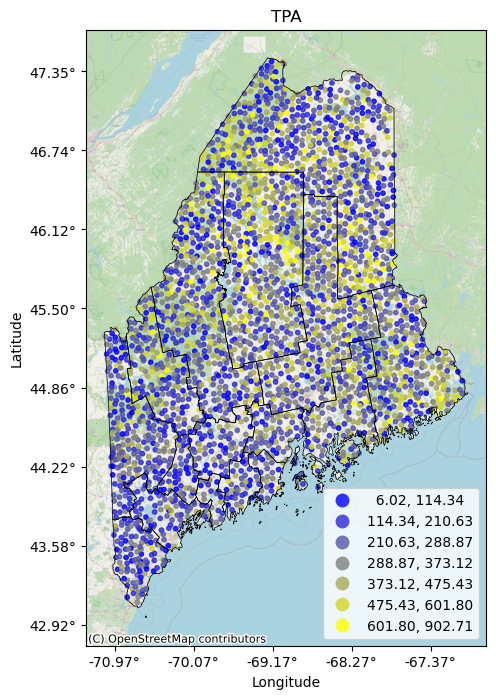

In [23]:
# Statewide plot-level trees per acre (TPA) visualization
savefile = f'_Results/{State}_TPA.png'
data     = '_Results/ME_Plot_Structure_Indices.csv'
var      = 'TPA'
vl.plot_forest_map(data=data,
                   var=var,
                   basemap=basemap,
                   FIPS=FIPS,
                   savefile=savefile)

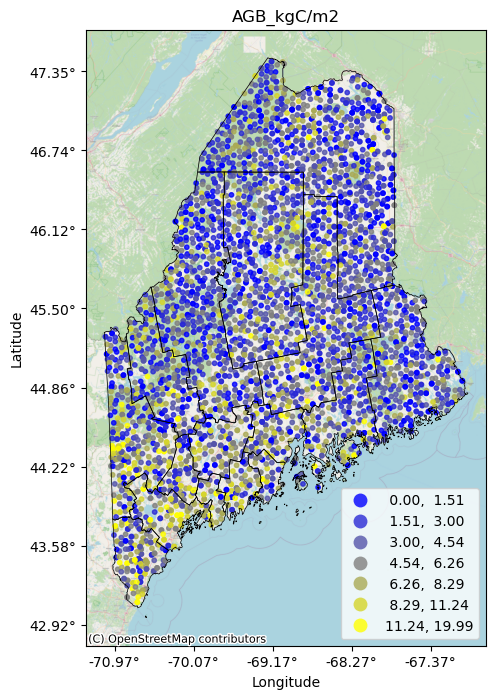

In [24]:
# Statewide plot-level above ground biomass (AGB) visualization
savefile = f'_Results/{State}_AGB.png'
data     = '_Results/ME_Plot_Biomass.csv'
var      = 'AGB_kgC/m2'
vl.plot_forest_map(data=data,
                   var=var,
                   basemap=basemap,
                   FIPS=FIPS,
                   savefile=savefile)

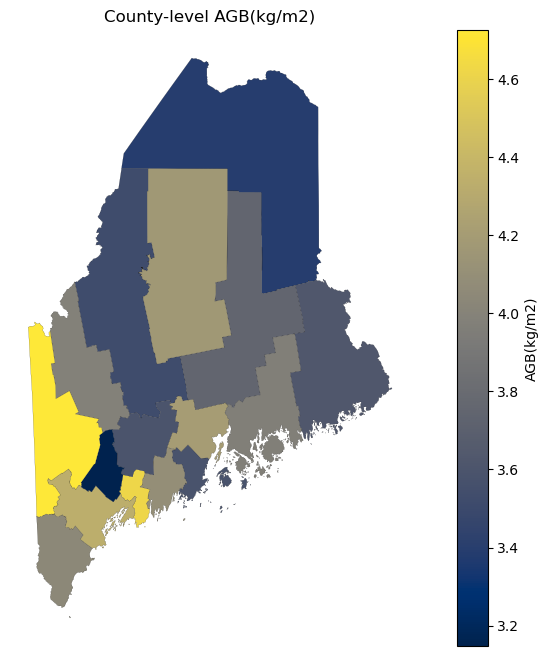

In [25]:
# County-level forest carbon density visualization
# Visualizes data by county instead of FIA plot 
savefile = f'_Results/{State}_County_Biomass_Density.png'
data     = '_Results/ME_County_Biomass_Density.csv'
var      = 'AGB(kg/m2)'
vl.county_biomass_map(data=data,
                      var=var,
                      basemap=basemap,
                      FIPS=FIPS,
                      savefile=savefile)

In [26]:
###----------------------------------------------------------------------------
# WALL-TO-WALL INTERPOLATED MAP
###----------------------------------------------------------------------------
# This function applies and interpolation function to display biomass wall-to-wall across a state

Forest AGB_kgC/m2 map saved to _Results/ME_Biomass_Map.tif


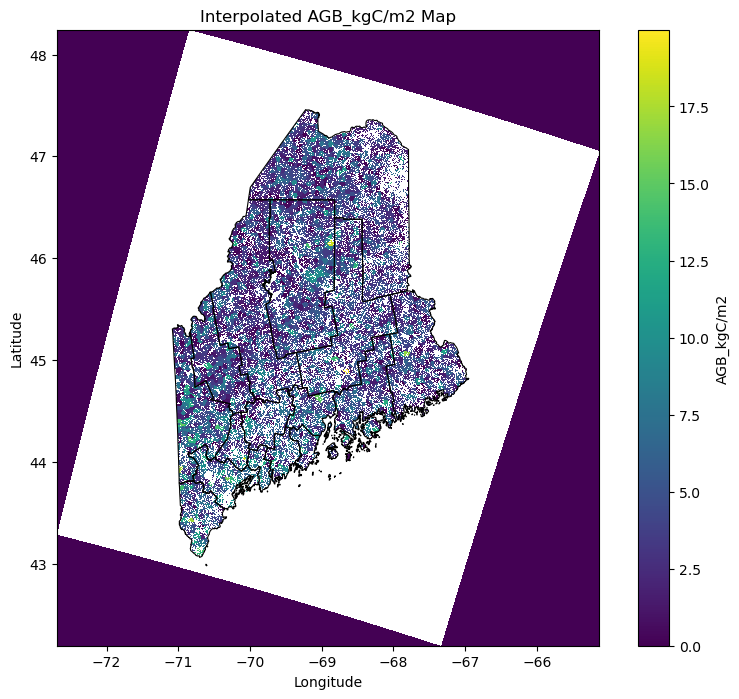

In [28]:
# Interpolate the state forest map with land cover
# Masks out areas that are not forest cover using a National Land Cover Database (NLCD) layer
# Clip the NLCD to your state of interest with GIS/coding software OR use pyFIA Tools to extract your state from the NLCD
# *NOTE*: This function can take a long time to run
land_cover = '_NLCD/NLCD_ME.tif' # NLCD, clipped to Maine
data       = '_Results/ME_Plot_Biomass.csv' 
var        = 'AGB_kgC/m2'
savefile   = f'_Results/{State}_Biomass_Map.tif'
ip.map_interpolate(data=data,
                   var=var,
                   basemap=basemap,       
                   FIPS=FIPS,
                   resolution = 0.01,       # Spatial resolution for interpolation in decimal degrees lat/long
                   interp_method='nearest', # Interpolation method, nearest neighbor
                   land_cover=land_cover,
                   savefile=savefile)

In [29]:
###----------------------------------------------------------------------------
# CLIMATE DATA APPLICATION AND ANALYSIS
###----------------------------------------------------------------------------
# Applies interpolated climate data from ClimateNA to each FIA plot in a state

In [31]:
# Extract climate data for each inventory plot
# *NOTE* : this function can take a LONG time to run
savefile = f'_Results/{State}_Plot_Biomass_Climate.csv'
data     = '_Results/ME_Plot_Biomass.csv'
cl.climate_data(data=data,                          
                climate_data='_Climate_Data',
                savefile=savefile)

eFFP.tif
EXT.tif
FFP.tif
MAP.tif
MAT.tif
MCMT.tif
MWMT.tif
NFFD.tif
PAS.tif
RH.tif
TD.tif


In [ ]:
###----------------------------------------------------------------------------
# BOOKKEEPING FOREST BIOMASS TRACKING
###----------------------------------------------------------------------------
# Function to summarize forest biomass over time

Regression Parameters:
a: 0.0736 ± 0.0212
b: 0.9809 ± 0.0628
R-squared: 0.7764


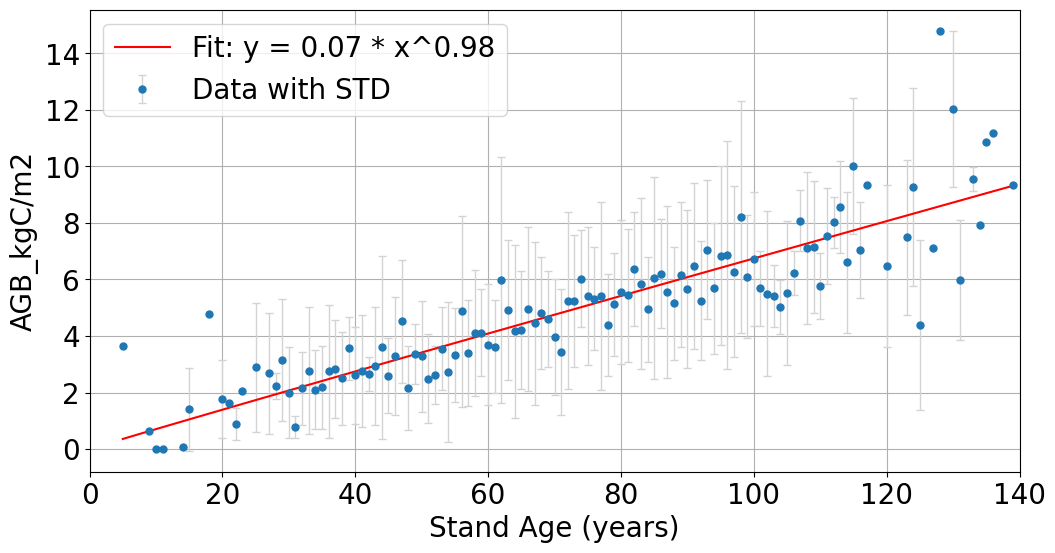

In [32]:
# Bookkeeping model: derive stand growth model parameters
data = '_Results/ME_Plot_Biomass.csv'
bk.stand_growth(data=data, 
                var = 'AGB_kgC/m2',     # Biomass AGB
                inv_yr=2023,            # The ending inventory year
                n_years=5,              # Inventory cycle (years)
                max_age=140,            # Maximum stand age
                forest_type=[801])      # Forest Type: sugar maple-beech-yellow birch

In [33]:
# Bookkeeping model: track the next year's forest biomass 
# This function uses clipped .TIFs from Maine
bk.bookkeeping(base_map = '_BK_Biomass/EXP_Biomass_2023.tif', # Base biomass map
               next_map = '_BK_Biomass/EXP_Biomass_2024.tif', # The next year biomass map
               frtp_map = '_BK_Biomass/EXP_Foresttype.tif',   # Forest type map
               dist_map = '_BK_Biomass/EXP_Disturbance.tif',  # Forest disturbance map 
               yr       = 24,                               # The distuabnce year
               par_file = '_BK_Biomass/EXP_paras.csv')